In [1]:
import pandas as pd

df = pd.read_parquet('../data/raw/yellow_tripdata_2025-09.parquet')

In [2]:
df.shape

(4251015, 20)

In [3]:
df.sample(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
4005730,2,2025-09-24 08:06:18,2025-09-24 08:26:55,NaN,2.19,NaN,None,137,140,0,15.11,0.0,0.5,0.00,0.0,1.0,19.86,NaN,NaN,0.75
3331768,2,2025-09-05 23:58:35,2025-09-06 00:42:28,NaN,9.29,NaN,None,100,61,0,-4.75,0.0,0.5,0.00,0.0,1.0,6.89,NaN,NaN,0.75
825765,2,2025-09-09 13:15:51,2025-09-09 13:49:02,1.0,6.72,1.0,N,137,198,1,35.90,0.0,0.5,8.13,0.0,1.0,48.78,2.5,0.0,0.75


In [4]:
df.isna().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1067195
trip_distance                  0
RatecodeID               1067195
store_and_fwd_flag       1067195
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1067195
Airport_fee              1067195
cbd_congestion_fee             0
dtype: int64

In [5]:
# ЧАСТЬ 1: ПРОПУСКИ И ДУБЛИКАТЫ
# строки с хотя бы одним NaN — это ровно те же строки, где payment_type == 0

df.index[df.isna().any(axis=1)].equals(df.index[df["payment_type"] == 0])

True

In [6]:
df[df.duplicated()].shape

(0, 20)

In [8]:
# ЧАСТЬ 2: МИНИМАЛЬНАЯ ОЧИСТКА ДАННЫХ
mask_1 = df["tpep_pickup_datetime"] > df["tpep_dropoff_datetime"]
mask_2 = (df["tpep_pickup_datetime"] == df["tpep_dropoff_datetime"]) & (df['trip_distance'] != 0)
mask_3 = (df["tpep_pickup_datetime"] < '2025-09-01') | (df["tpep_pickup_datetime"] >= '2025-10-01')
df[mask_1 | mask_2 | mask_3]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
321,7,2025-09-01 00:09:56,2025-09-01 00:09:56,2.0,1.44,1.0,N,158,186,1,9.30,0.0,0.5,0.00,0.0,1.0,15.05,2.5,0.0,0.75
322,7,2025-09-01 00:26:22,2025-09-01 00:26:22,2.0,1.05,1.0,N,234,114,1,7.90,0.0,0.5,2.73,0.0,1.0,16.38,2.5,0.0,0.75
323,7,2025-09-01 00:54:14,2025-09-01 00:54:14,1.0,4.59,1.0,N,114,181,1,26.10,0.0,0.5,2.00,0.0,1.0,33.85,2.5,0.0,0.75
374,7,2025-09-01 00:20:02,2025-09-01 00:20:02,1.0,4.34,1.0,N,48,87,1,20.50,0.0,0.5,7.88,0.0,1.0,34.13,2.5,0.0,0.75
375,7,2025-09-01 00:46:16,2025-09-01 00:46:16,1.0,1.24,1.0,N,231,148,1,9.30,0.0,0.5,3.01,0.0,1.0,18.06,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3793940,2,2025-09-18 08:52:00,2025-09-18 08:52:00,NaN,0.01,NaN,None,74,74,0,9.22,0.0,0.5,0.00,0.0,1.0,10.72,NaN,NaN,0.00
3836104,2,2025-09-19 10:02:00,2025-09-19 10:02:00,NaN,0.01,NaN,None,143,143,0,-4.75,0.0,0.5,0.00,0.0,1.0,3.00,NaN,NaN,0.75
3878177,2,2025-09-20 09:34:00,2025-09-20 09:34:00,NaN,0.10,NaN,None,48,48,0,4.32,0.0,0.5,0.00,0.0,1.0,9.07,NaN,NaN,0.75
4031291,2,2025-09-25 04:49:00,2025-09-25 04:49:00,NaN,0.06,NaN,None,61,61,0,38.94,0.0,0.5,0.00,0.0,1.0,40.44,NaN,NaN,0.00


In [9]:
# проблемных строк 55983
# 55983 записей составляют ~1.3% от размера всей выборки, удалим эти записи
df = df[~(mask_1 | mask_2 | mask_3)]

In [10]:
# проверяю PULocationID, DOLocationID
zones = pd.read_csv("../data/raw/taxi_zone_lookup.csv")
valid_ids = set(zones["LocationID"])
print('записей с несуществующими зонами посадки:', df[~(df["PULocationID"].isin(valid_ids))].shape[0])
print('записей с несуществующими зонами высадки:', df[~(df["DOLocationID"].isin(valid_ids))].shape[0])

записей с несуществующими зонами посадки: 0
записей с несуществующими зонами высадки: 0


In [11]:
df[df["PULocationID"] == 264]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1541,1,2025-09-01 00:45:39,2025-09-01 00:52:30,2.0,1.70,1.0,N,264,7,1,9.30,1.00,0.5,2.95,0.0,1.0,14.75,0.0,0.0,0.00
1926,1,2025-09-01 00:01:08,2025-09-01 00:08:28,2.0,0.80,1.0,N,264,264,1,8.60,4.25,0.5,2.85,0.0,1.0,17.20,2.5,0.0,0.75
1927,1,2025-09-01 00:11:29,2025-09-01 00:20:27,2.0,1.50,1.0,N,264,264,1,10.70,4.25,0.5,4.00,0.0,1.0,20.45,2.5,0.0,0.75
3632,1,2025-09-01 01:01:59,2025-09-01 01:20:46,1.0,8.00,1.0,N,264,264,1,33.10,3.50,0.5,1.50,0.0,1.0,39.60,2.5,0.0,0.00
3650,1,2025-09-01 01:00:40,2025-09-01 01:08:32,2.0,0.90,1.0,N,264,79,1,9.30,4.25,0.5,3.00,0.0,1.0,18.05,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4228098,2,2025-09-30 08:01:48,2025-09-30 08:48:27,NaN,9.15,NaN,None,264,264,0,51.90,0.00,0.5,0.00,0.0,1.0,53.40,NaN,NaN,0.00
4233301,2,2025-09-30 14:42:10,2025-09-30 15:15:39,NaN,0.00,NaN,None,264,264,0,39.71,0.00,0.5,0.00,0.0,1.0,43.71,NaN,NaN,0.00
4235796,2,2025-09-30 16:35:34,2025-09-30 17:09:50,NaN,0.00,NaN,None,264,264,0,41.93,0.00,0.5,0.00,0.0,1.0,43.43,NaN,NaN,0.00
4236067,1,2025-09-30 16:57:39,2025-09-30 17:44:28,NaN,16.30,NaN,None,264,264,0,70.00,5.00,0.5,11.96,0.0,1.0,91.71,NaN,NaN,0.75


In [12]:
# записей с зоной 264 всего 6080
# Для анализа локального спроса нужна известная зона посадки, поэтому удаляю их.
df = df[df["PULocationID"] != 264]

In [13]:
# ЧАСТЬ 3: EDA
print('удалено записей из таблицы:', 4251015-df.shape[0])
print('осталось записей о поездке:', df.shape[0])
print('максимальная и минимальная даты в таблице:', df['tpep_pickup_datetime'].max(), df['tpep_pickup_datetime'].min())

удалено записей из таблицы: 62063
осталось записей о поездке: 4188952
максимальная и минимальная даты в таблице: 2025-09-30 23:59:59 2025-09-01 00:00:00


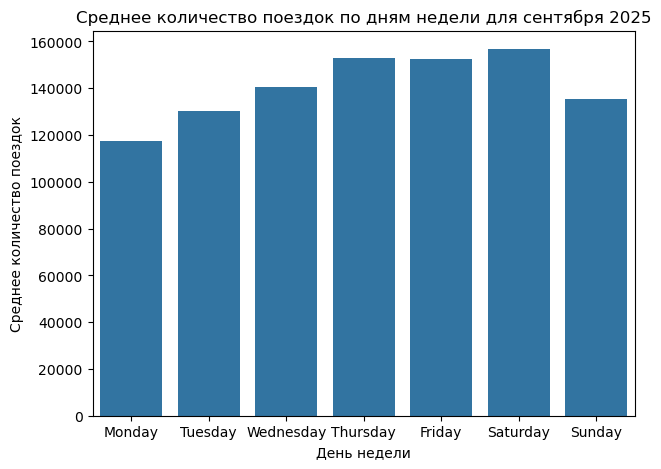

In [14]:
# рассмотрим распределение записей по дням недели (считая для начала поездки) и визуализируем
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))
first_group = df.groupby(df['tpep_pickup_datetime'].dt.date).size()
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
second_group = first_group.groupby(pd.to_datetime(first_group.index).day_name()).mean()
second_group = second_group.reindex(weekday_order)
sns.barplot(data=second_group).set(title='Среднее количество поездок по дням недели для сентября 2025',
                                   xlabel='День недели',
                                   ylabel='Среднее количество поездок');

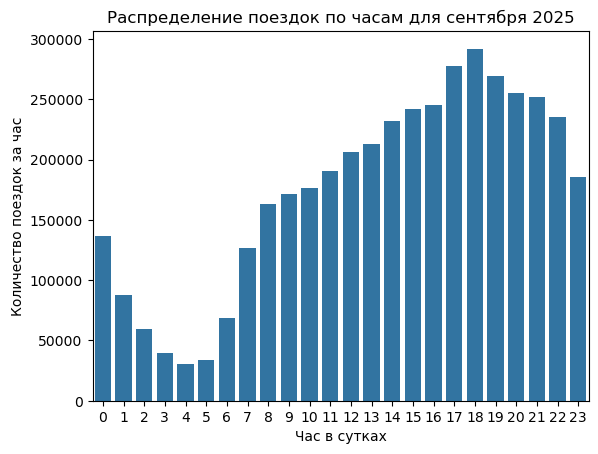

In [15]:
# рассмотрим распределение записей по часам и визуализируем
gr = df.groupby(df['tpep_pickup_datetime'].dt.hour).size()
sns.barplot(data=gr).set(
    title='Распределение поездок по часам для сентября 2025', 
    xlabel='Час в сутках', 
    ylabel='Количество поездок за час');

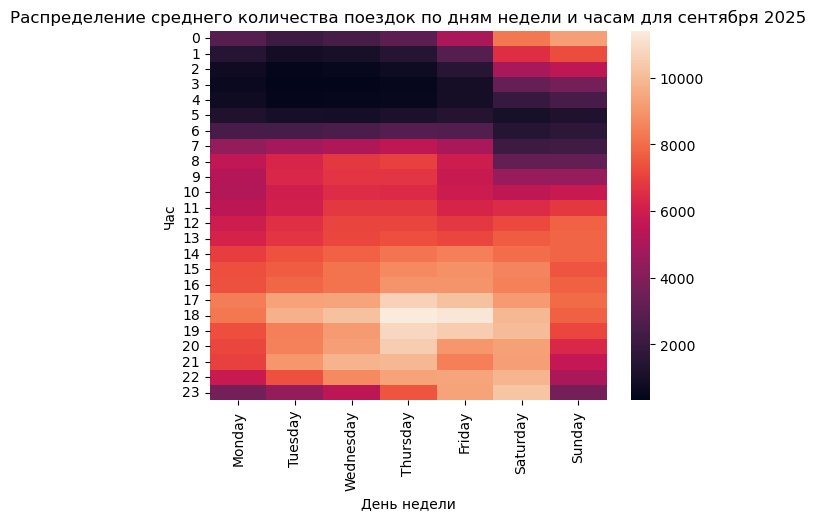

In [16]:
# Посмотрим среднее количество поездок по дню недели и часу
day_hour = df.groupby([
    df["tpep_pickup_datetime"].dt.date.rename("date"), 
    df["tpep_pickup_datetime"].dt.day_name().rename("day_of_week"), 
    df["tpep_pickup_datetime"].dt.hour.rename("hour")]).size().rename("trips")
day_hour = day_hour.reset_index()

day_hour = day_hour.groupby([
    day_hour["day_of_week"],
    day_hour["hour"]])["trips"].mean()
day_hour = day_hour.reset_index()


day_hour = day_hour.pivot(columns="day_of_week", index="hour", values="trips")
day_hour = day_hour[weekday_order]

sns.heatmap(day_hour).set(title="Распределение среднего количества поездок по дням недели и часам для сентября 2025", 
                          xlabel="День недели", 
                          ylabel="Час");

In [17]:
# Первые 2 графика распределений не имеют значимых отличий от августовских.
# Хитмап показывает, что активный период поездок теперь не в среду, а снова в четверг вечером
# Пик приходится на 18 ч, также количество поездок возросло в пятницу и субботу вечером.

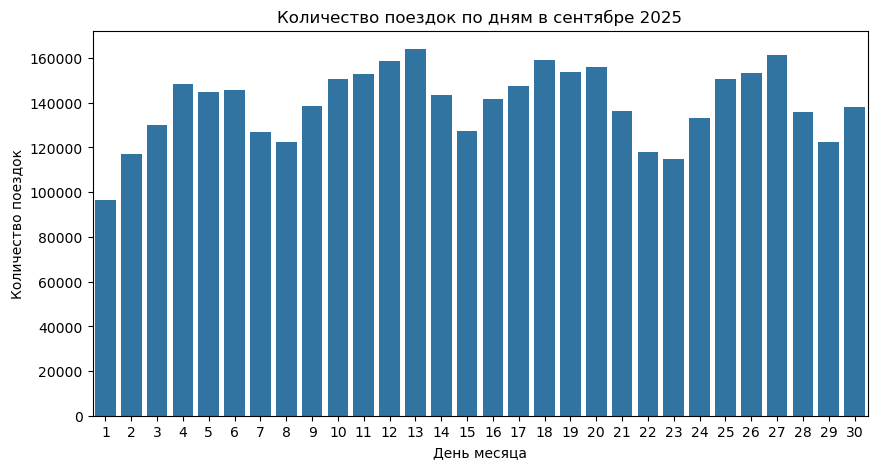

In [19]:
# Рассмотрим спрос на такси в конкретные даты

from datetime import date


gr_date = df.groupby(df["tpep_pickup_datetime"].dt.date.rename("date")).size().rename("trips")
gr_date = gr_date.to_frame()

gr_date = gr_date.reset_index()
gr_date["date"] = pd.to_datetime(gr_date["date"])
gr_date["date"] = gr_date["date"].dt.day

plt.figure(figsize=(10, 5))
sns.barplot(data=gr_date, x="date", y="trips").set(
    title="Количество поездок по дням в сентябре 2025", 
    xlabel="День месяца", 
    ylabel="Количество поездок");

# Недельная цикличность сохраняется.
# Особенно низкие значения наблюдаются по понедельникам: 1, 8, 15, 22, 29 сентября.
# Интересно, что 1 сентября происходит сильный спад количества поездок, я думала, это связано с началом
# учебного года. Однако в США учебный год начинается не обязательно в сентябре. 
# В первый понедельник сентября американцы отмечают День труда, вот что о нём пишут:
# 'Традиционно День труда воспринимается многими как символический конец лета. 
# В этот день многие американцы берут отпуск, чтобы провести длинные выходные с семьёй или друзьями.'

In [20]:
# Зона посадки PULocationID

start_zone_borough = df.groupby(df["PULocationID"]).size().rename("trips")
start_zone_borough = start_zone_borough.to_frame()
start_zone_borough = start_zone_borough.merge(zones[["LocationID", "Borough", "Zone"]], left_index=True, right_on='LocationID')
start_zone_borough = start_zone_borough.set_index("LocationID")
start_borough = start_zone_borough.groupby(start_zone_borough["Borough"])["trips"].sum().sort_values()
start_borough = start_borough.to_frame()
start_borough
# ожидаемо, поездки на жёлтых такси всё так же преобладают на Манхэттене

,trips
Borough,
Staten Island,437
EWR,550
Bronx,30188
Brooklyn,163327
Queens,411122
Manhattan,3581200


In [21]:
# ЧАСТЬ 4: ИСКОМЫЕ ДАННЫЕ
venue_zone_ids = [79, 161, 163, 186, 239]

df_selected = df[
    df["PULocationID"].isin(venue_zone_ids)
]

data_pickup = (
    df_selected
    .groupby([
        df_selected["tpep_pickup_datetime"].dt.floor("D").rename("date"),
        df_selected["tpep_pickup_datetime"].dt.hour.rename("hour"),
        df_selected["PULocationID"].rename("LocationID")
    ])
    .size()
    .rename("pickups")
    .reset_index()
)

data_pickup

,date,hour,LocationID,pickups
0,2025-09-01,0,79,215
1,2025-09-01,0,161,38
2,2025-09-01,0,163,43
3,2025-09-01,0,186,349
4,2025-09-01,0,239,50
...,...,...,...,...
3591,2025-09-30,23,79,159
3592,2025-09-30,23,161,252
3593,2025-09-30,23,163,115
3594,2025-09-30,23,186,95


In [22]:
# В таблице должно быть 30 дней x 24 часа x 5 зон = 3600 записей, сейчас в таблице 3596 записей.

full_index = pd.MultiIndex.from_product(
    [
        pd.date_range("2025-09-01", "2025-09-30", freq="D"),
        range(24),
        venue_zone_ids
    ],
    names=["date", "hour", "LocationID"]
)

data_pickup = (
    data_pickup
    .set_index(["date", "hour", "LocationID"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

assert (
    data_pickup["pickups"].sum()
    ==
    df["PULocationID"].isin(venue_zone_ids).sum()
)

data_pickup

,date,hour,LocationID,pickups
0,2025-09-01,0,79,215
1,2025-09-01,0,161,38
2,2025-09-01,0,163,43
3,2025-09-01,0,186,349
4,2025-09-01,0,239,50
...,...,...,...,...
3595,2025-09-30,23,79,159
3596,2025-09-30,23,161,252
3597,2025-09-30,23,163,115
3598,2025-09-30,23,186,95


In [23]:
# ЧАСТЬ 5: СОХРАНЕНИЕ ОБРАБОТАННЫХ ДАННЫХ

from pathlib import Path

processed_taxi_dir = Path("../data/processed/taxi")
processed_taxi_dir.mkdir(parents=True, exist_ok=True)

output_path = (
    processed_taxi_dir
    / "yellow_taxi_pickups_2025_09.parquet"
)

data_pickup.to_parquet(
    output_path,
    index=False
)

In [24]:
data_pickup_check = pd.read_parquet(output_path)

print("Размер:", data_pickup_check.shape)
print(
    "Дубликаты:",
    data_pickup_check.duplicated(
        subset=["date", "hour", "LocationID"]
    ).sum()
)
print("Пропуски:", data_pickup_check.isna().sum().sum())
print("Количество зон:", data_pickup_check["LocationID"].nunique())

assert data_pickup_check.equals(data_pickup)

Размер: (3600, 4)
Дубликаты: 0
Пропуски: 0
Количество зон: 5
